In [ ]:
import numpy as np
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import cv2 as cv
from sklearn.preprocessing import StandardScaler
from rich.progress import track
import os
import numpy as np
from cachetools import cached

In [57]:
CATEGORIES = ("Lotus", "Tulip", "Orchid", "Lilly", "Sunflower")
DATASET_PATH = "./data/flowers"
IMG_SIZE = 128

Output()

(800, 16384)


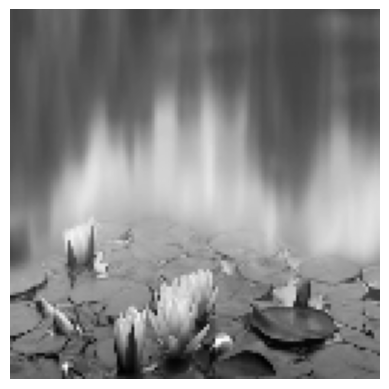

In [91]:
@cached({})
def load_dataset(path: str):
    files = os.listdir(path)
    data = []
    for file in track(files, description=f"Loading dataset from {path}"):
        img = cv.imread(os.path.join(path, file))
        assert img is not None, "Image not found"
        img = cv.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        img = img.flatten()
        data.append(img)
    return np.array(data)


lilly_df = load_dataset(os.path.join(DATASET_PATH, "train", CATEGORIES[0]))
print(lilly_df.shape)
plt.imshow(lilly_df[0].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
plt.axis("off")
plt.show()

In [92]:
X_train = load_dataset(os.path.join(DATASET_PATH, "train", CATEGORIES[0]))
Y_train = 0 * np.ones(len(X_train)) 
for i in range(1, len(CATEGORIES)):
    category_data = load_dataset(os.path.join(DATASET_PATH, "train", CATEGORIES[i]))
    X_train = np.vstack(
        [X_train] + [category_data]
    )
    Y_train = np.hstack(
        [Y_train] + [i * np.ones(len(category_data))]
    )

X_test = load_dataset(os.path.join(DATASET_PATH, "val", CATEGORIES[0]))
Y_test = 0 * np.ones(len(X_test)) 
for i in range(1, len(CATEGORIES)):
    category_data = load_dataset(os.path.join(DATASET_PATH, "val", CATEGORIES[i]))
    X_test = np.vstack(
        [X_test] + [category_data]
    )
    Y_test = np.hstack(
        [Y_test] + [i * np.ones(len(category_data))]
    )

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

In [60]:
class AbstractClassifier(ABC):
    @abstractmethod
    def fit(self, X: np.ndarray, y: np.ndarray):
        pass

    @abstractmethod
    def predict(self, X: np.ndarray) -> np.ndarray:
        pass


In [97]:
class OneLayerNN(AbstractClassifier):
    def __init__(self, input_size: int, output_size: int):
        self.input_size = input_size
        self.output_size = output_size
        # Xavier initialization for sigmoid (gain=1)
        self.weights = np.random.randn(input_size + 1, output_size) * np.sqrt(1.0 / input_size)
        self.cache = {}

    def softmax(self, z):
        # Stable softmax
        z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def cross_entropy_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        # Avoid log(0)
        y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
        return - (1 / m) * np.sum(y_true * np.log(y_pred))

    def forward(self, X):
        z = np.dot(X, self.weights)
        self.cache["X"] = X
        self.cache["z"] = z
        a = self.softmax(z)          # Softmax activation
        self.cache["a"] = a
        return a

    def backward(self, X, y, learning_rate):
        m = X.shape[0]
        a = self.cache["a"]

        # Gradient of cross-entropy with softmax is simply (a - y) / m
        dL_dz = (a - y) / m

        dL_dw = np.dot(X.T, dL_dz)

        # clip_value = 5.0
        # dL_dw = np.clip(dL_dw, -clip_value, clip_value)

        # Update weights
        self.weights -= learning_rate * dL_dw
        self.cache = {}   # clear cache

    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        epochs: int = 1000,
        learning_rate: float = 0.1,
        log_interval: int = 100,
        shuffle: bool = True,
        random_seed: int = 42
    ):
        # Normalize inputs (important for sigmoid/softmax)
        # You should do this outside, but included as safeguard
        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X)

        X_with_bias = np.hstack((X_train_scaled, np.ones((X_train_scaled.shape[0], 1))))

        # One-hot encode labels
        encoder = OneHotEncoder(sparse_output=False)
        y_encoded = encoder.fit_transform(y.reshape(-1, 1))

        if random_seed is not None:
            np.random.seed(random_seed)

        errors = []
        for epoch in track(range(epochs), description="Training..."):
            if shuffle:
                indices = np.random.permutation(X_with_bias.shape[0])
                X_batch = X_with_bias[indices]
                y_batch = y_encoded[indices]
            else:
                X_batch = X_with_bias
                y_batch = y_encoded

            preds = self.forward(X_batch)

            # Loss
            loss = self.cross_entropy_loss(y_batch, preds)
            errors.append(loss)

            epoch_learning_rate = learning_rate * (0.95 ** (epoch // 100)) 
            self.backward(X_batch, y_batch, epoch_learning_rate)

            # Logging
            if (epoch + 1) % log_interval == 0:
                predictions = np.argmax(preds, axis=1)
                actual = np.argmax(y_batch, axis=1)
                accuracy = np.mean(predictions == actual)

                val_preds = self.predict(X_test)
                val_accuracy = np.mean(val_preds == Y_test)
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, "
                      f"Accuracy: {accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}, Weight norm: {np.linalg.norm(self.weights):.4f}")

                if np.all(predictions == predictions[0]):
                    print("WARNING: All predictions are identical!")

        return errors

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = X.astype(np.float32)
        X_scaled = self.scaler.transform(X)
        X_with_bias = np.hstack((X_scaled, np.ones((X_scaled.shape[0], 1))))
        a = self.forward(X_with_bias)
        return np.argmax(a, axis=1)



Output()

Epoch 100/5000, Loss: 5.2396, Accuracy: 0.3268, Validation Accuracy: 0.2799, Weight norm: 2.2951

Epoch 200/5000, Loss: 4.4831, Accuracy: 0.3680, Validation Accuracy: 0.2888, Weight norm: 2.4076

Epoch 300/5000, Loss: 3.9034, Accuracy: 0.4014, Validation Accuracy: 0.3046, Weight norm: 2.5414

Epoch 400/5000, Loss: 3.3855, Accuracy: 0.4429, Validation Accuracy: 0.3116, Weight norm: 2.6771

...

Epoch 4600/5000, Loss: 0.3327, Accuracy: 0.9491, Validation Accuracy: 0.6429, Weight norm: 3.7707

Epoch 4700/5000, Loss: 0.3315, Accuracy: 0.9496, Validation Accuracy: 0.6439, Weight norm: 3.7753

Epoch 4800/5000, Loss: 0.3303, Accuracy: 0.9499, Validation Accuracy: 0.6449, Weight norm: 3.7797

Epoch 4900/5000, Loss: 0.3292, Accuracy: 0.9501, Validation Accuracy: 0.6459, Weight norm: 3.7839

Epoch 5000/5000, Loss: 0.3282, Accuracy: 0.9503, Validation Accuracy: 0.6469, Weight norm: 3.7878

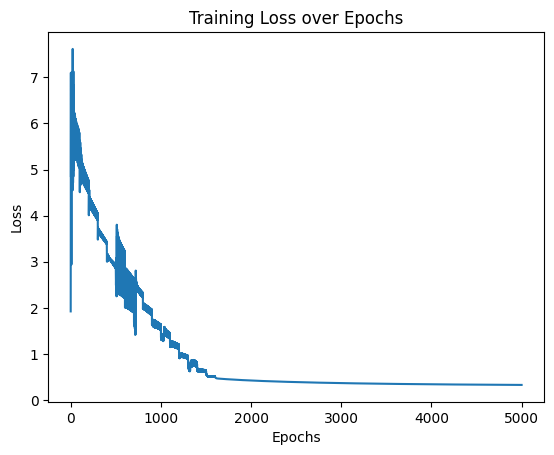

In [98]:
model = OneLayerNN(input_size=IMG_SIZE * IMG_SIZE, output_size=5)
errors = model.fit(X_train, Y_train, log_interval=100, epochs=5000, learning_rate=0.005)
plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.show()

Test Accuracy: 0.6469


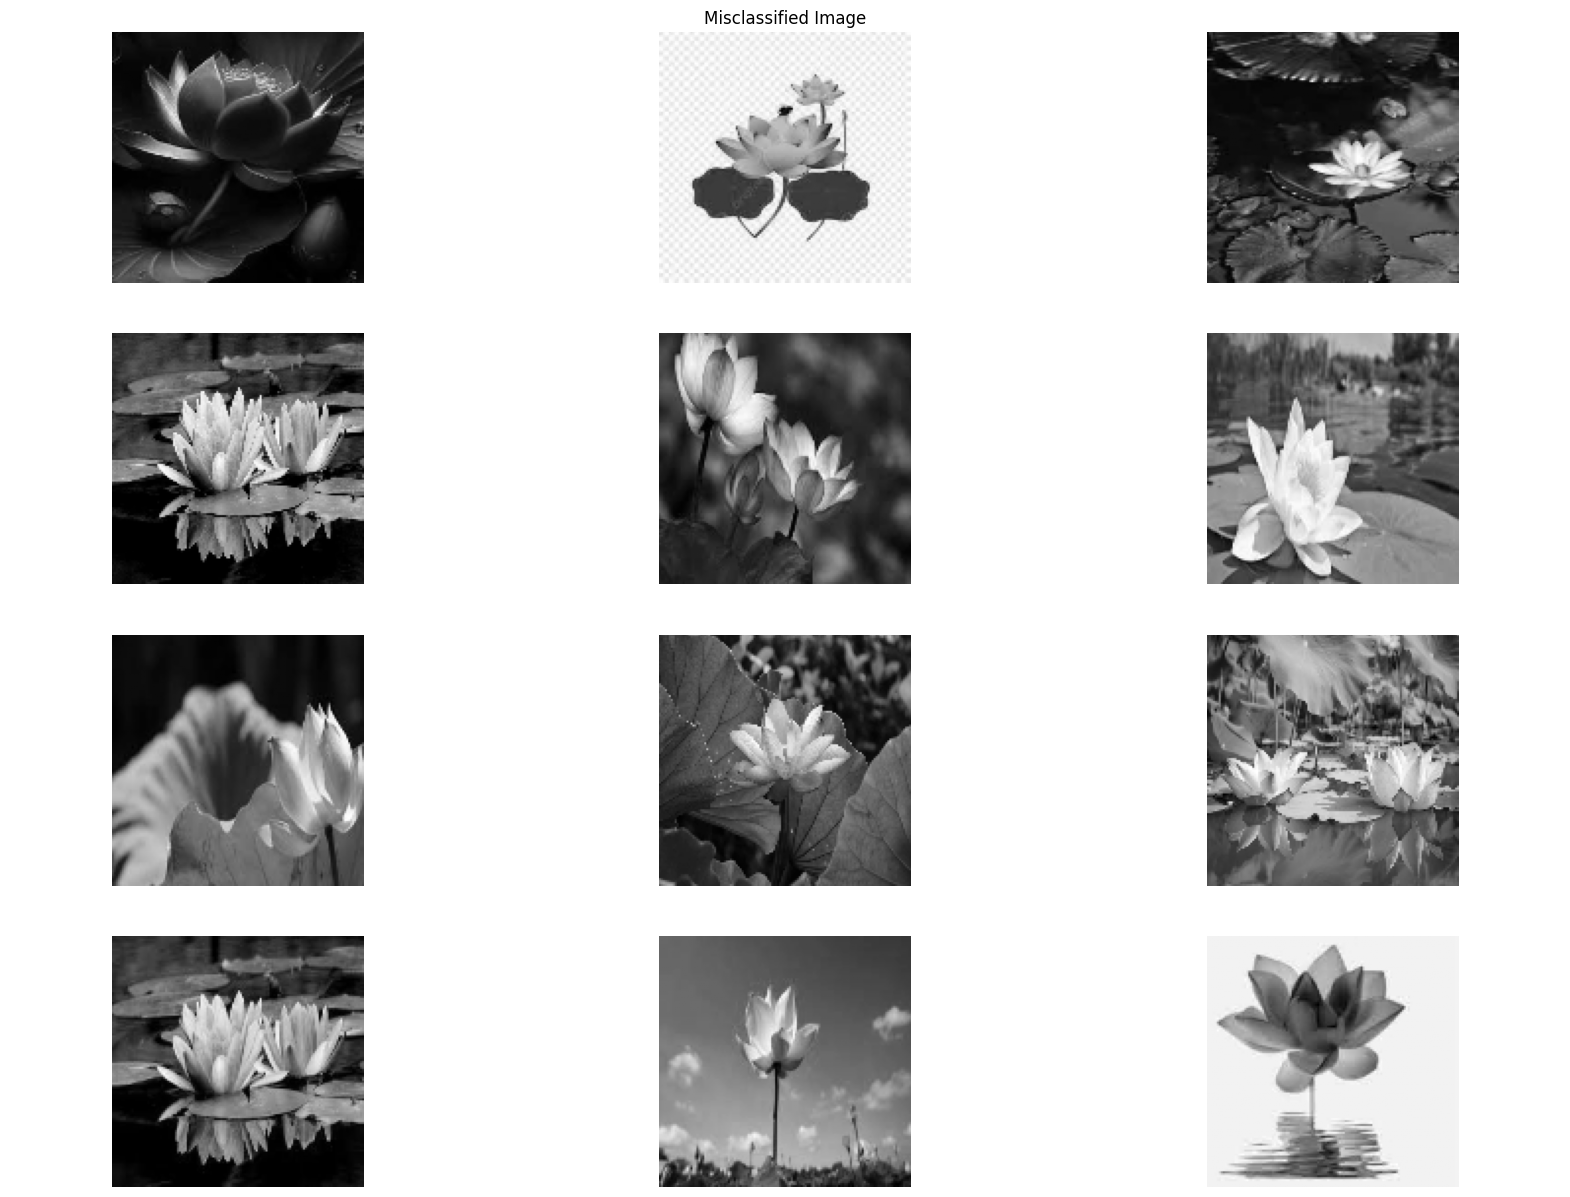

In [118]:
preds = model.predict(X_test)
accuracy = np.mean(preds == Y_test)
print(f"Test Accuracy: {accuracy:.4f}")
# first image to missclassify

r = 4
c = 3

missclassified =  X_test[(preds != Y_test)]

plt.figure(figsize=(20, 15))
plt.title("Misclassified Image")
plt.axis("off")
for i in range(r):
    for j in range(c):
        plt.subplot(r, c, i * c + j + 1)
        img = missclassified[i * c + j].reshape(IMG_SIZE, IMG_SIZE)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
plt.show()

In [ ]:
class TwoLayerNN(AbstractClassifier):
    def __init__(self, input_size: int, hidden_layer_size: int, output_size: int):
        self.input_size = input_size
        self.output_size = output_size
        # Xavier initialization for sigmoid (gain=1)
        self.weights1 = np.random.randn(input_size + 1, hidden_layer_size) * np.sqrt(1.0 / input_size)
        self.weights2 = np.random.randn(hidden_layer_size, output_size) * np.sqrt(1.0 / hidden_layer_size)
        self.cache = {}

    def softmax(self, z):
        # Stable softmax
        z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def cross_entropy_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        # Avoid log(0)
        y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
        return - (1 / m) * np.sum(y_true * np.log(y_pred))

    def forward(self, X):
        z = np.dot(X, self.weights)
        self.cache["X"] = X
        self.cache["z"] = z
        a = self.softmax(z)          # Softmax activation
        self.cache["a"] = a
        return a

    def backward(self, X, y, learning_rate):
        m = X.shape[0]
        a = self.cache["a"]

        # Gradient of cross-entropy with softmax is simply (a - y) / m
        dL_dz = (a - y) / m

        dL_dw = np.dot(X.T, dL_dz)

        # clip_value = 5.0
        # dL_dw = np.clip(dL_dw, -clip_value, clip_value)

        # Update weights
        self.weights -= learning_rate * dL_dw
        self.cache = {}   # clear cache

    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        epochs: int = 1000,
        learning_rate: float = 0.1,
        log_interval: int = 100,
        shuffle: bool = True,
        random_seed: int = 42
    ):
        # Normalize inputs (important for sigmoid/softmax)
        # You should do this outside, but included as safeguard
        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X)

        X_with_bias = np.hstack((X_train_scaled, np.ones((X_train_scaled.shape[0], 1))))

        # One-hot encode labels
        encoder = OneHotEncoder(sparse_output=False)
        y_encoded = encoder.fit_transform(y.reshape(-1, 1))

        if random_seed is not None:
            np.random.seed(random_seed)

        errors = []
        for epoch in track(range(epochs), description="Training..."):
            if shuffle:
                indices = np.random.permutation(X_with_bias.shape[0])
                X_batch = X_with_bias[indices]
                y_batch = y_encoded[indices]
            else:
                X_batch = X_with_bias
                y_batch = y_encoded

            preds = self.forward(X_batch)

            # Loss
            loss = self.cross_entropy_loss(y_batch, preds)
            errors.append(loss)

            epoch_learning_rate = learning_rate * (0.95 ** (epoch // 100)) 
            self.backward(X_batch, y_batch, epoch_learning_rate)

            # Logging
            if (epoch + 1) % log_interval == 0:
                predictions = np.argmax(preds, axis=1)
                actual = np.argmax(y_batch, axis=1)
                accuracy = np.mean(predictions == actual)

                val_preds = self.predict(X_test)
                val_accuracy = np.mean(val_preds == Y_test)
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, "
                      f"Accuracy: {accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}, Weight norm: {np.linalg.norm(self.weights):.4f}")

                if np.all(predictions == predictions[0]):
                    print("WARNING: All predictions are identical!")

        return errors

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = X.astype(np.float32)
        X_scaled = self.scaler.transform(X)
        X_with_bias = np.hstack((X_scaled, np.ones((X_scaled.shape[0], 1))))
        a = self.forward(X_with_bias)
        return np.argmax(a, axis=1)

